## **BIA 810 - Healthcare Advanced Analytics - Final Project**

### **Problem Statement**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
The anesthesia drug market is a segment of the pharmaceutical industry that focuses on the development,
production, and distribution of medications used to induce and maintain anesthesia during medical
procedures and surgeries. The market for anesthesia drugs encompasses a wide range of pharmaceutical
products, including general anesthetics, local anesthetics, and adjunctive drugs that support the
anesthesia process. The demand for these drugs is closely tied to the healthcare industry, as the number
of surgical procedures, including both routine and complex surgeries, continues to grow worldwide.
Factors such as an aging population, increased healthcare access, and advancements in medical
technology contribute to the expansion of the anesthesia drug market.<br><br>
You are a Healthcare Commercial Analytics leader working for anesthesia drugs portfolio at a big pharma
company. As an analytics leader, understanding market dynamics and making evidence-based decisions
are crucial for the success of the business. Your company has a market leading brand <span style="background-color:#7FA7C9; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 1- <strong>J1885</strong></span> in the
anesthesia portfolio. Your company also has recently launched a variant of the same brand <span style="background-color:#163A5F; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 2- <strong>J2250</strong></span> in
the market which is supposed to cannibalize your leading brand. (Market cannibalization is a loss in sales
caused by a company's introduction of a new product that displaces one of its own older products in the
market. The cannibalization of existing products need not necessarily lead to an increase in the company's
overall market share, but at least the sales growth for the new product should be at the expense of the
drop in sales of the old product.)<br><br>
However, the expected cannibalization is not happening in the market. It appears that instead of your
new product capturing the dropping sales of your old product, one of your competitors <span style="background-color:#FA7F3C; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 3- <strong>J3010</strong></span> is
rapidly gaining market share, leaving your new product <span style="background-color:#163A5F; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 2- <strong>J2250</strong></span> to lose its expected market share.<br><br>
Though <span style="background-color:#FA7F3C; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 3- <strong>J3010</strong></span> is the primary competitor brand, this product absorbing the market share is also a threat for your brands. So, consider <span style="background-color:#F5C06A; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product 4- <strong>J2704</strong></span> as a competitor brand as well.
</div>

In [161]:
import numpy as np
import pandas as pd

In [162]:
pd.set_option('display.max_columns', None)

### **0. Analytics-Ready Dataset Preparation**

#### 0.1.1 Organize Medicare Claims Data

In [163]:
claims_1_raw =  pd.read_csv("/content/Medicare_Claims_data_part_1.csv")
claims_1_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1272380,10791,1.316539e+09,11/8/2016,11/7/2016,S81811D,154.73,11182.21567,11.0,G8996,-0.04,12.0,Z951,NaN,NaN,NaN,NaN
1,631196,10107,1.033202e+09,7/21/2016,7/12/2016,S0083XA,NaN,NaN,1.0,76700,2.57,NaN,I10,NaN,NaN,8.86,69
2,1548564,10412,1.880497e+09,7/14/2018,5/20/2018,R918,NaN,NaN,1.0,C1751,53.81,NaN,I10,NaN,NaN,86.40,30
3,1427731,10934,1.655569e+09,6/19/2016,7/15/2016,I2119,705.89,20750.00517,17.0,85378,-5.91,7.0,M25552,NaN,NaN,NaN,NaN
4,428779,965,1.644309e+09,3/21/2017,8/10/2018,C4490,2884.15,18437.66432,5.0,80061,2.62,6.0,Z9049,NaN,NaN,NaN,NaN


In [164]:
claims_1 = claims_1_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_1

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1272380,11/8/2016,10791,1.316539e+09,Z951,G8996
1,631196,7/21/2016,10107,1.033202e+09,I10,76700
2,1548564,7/14/2018,10412,1.880497e+09,I10,C1751
3,1427731,6/19/2016,10934,1.655569e+09,M25552,85378
4,428779,3/21/2017,965,1.644309e+09,Z9049,80061
...,...,...,...,...,...,...
199995,201316,7/31/2016,12551,1.447581e+09,I10,84132
199996,1139560,3/26/2017,13193,1.172104e+09,I10,84460
199997,1422020,12/15/2018,11766,1.840282e+09,G311,J2060
199998,276481,10/2/2016,12995,1.676423e+09,I10,80048


In [165]:
claims_2_raw =  pd.read_csv("/content/Medicare_Claims_data_part_2.csv")
claims_2_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1089764,10064,1.775153e+09,11/10/2017,3/9/2018,C439,NaN,NaN,1.0,99284,8.13,NaN,I10,NaN,NaN,7.71,30
1,677005,1174,1.585740e+09,8/25/2016,7/27/2016,R1011,NaN,NaN,4.0,86921,1.24,NaN,I10,NaN,NaN,8.55,69
2,751112,12093,1.474716e+09,2/14/2018,5/5/2018,Z951,NaN,NaN,1.0,97530,51.67,NaN,I10,NaN,NaN,100.83,8
3,569047,10773,1.300394e+09,4/8/2016,6/16/2016,D500,NaN,NaN,1.0,73522,130.49,NaN,I10,NaN,NaN,67.01,41
4,1244504,11998,1.788795e+09,3/2/2017,10/13/2016,K210,282.61,8810.400285,1.0,47563,38.53,4.0,M5032,NaN,NaN,NaN,NaN


In [166]:
claims_2 = claims_2_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_2

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1089764,11/10/2017,10064,1.775153e+09,I10,99284
1,677005,8/25/2016,1174,1.585740e+09,I10,86921
2,751112,2/14/2018,12093,1.474716e+09,I10,97530
3,569047,4/8/2016,10773,1.300394e+09,I10,73522
4,1244504,3/2/2017,11998,1.788795e+09,M5032,47563
...,...,...,...,...,...,...
199995,240671,5/30/2018,10217,1.813622e+09,R197,71046
199996,779254,10/16/2017,10678,1.685051e+09,E1142,36415
199997,271289,2/26/2018,10063,1.582805e+09,I10,22851
199998,1160940,8/31/2017,10491,1.658547e+09,R197,73564


In [167]:
claims_3_raw =  pd.read_csv("/content/Medicare_Claims_data_part_3.csv")
claims_3_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1644551,11443,1.519584e+09,2/10/2018,10/20/2017,I119,NaN,NaN,1.0,83615,54.43,NaN,I10,NaN,NaN,74.65,93
1,168172,10738,1.896665e+09,11/6/2017,12/7/2017,C679,NaN,NaN,1.0,36415,72.02,NaN,I10,NaN,NaN,119.10,69
2,1076245,12980,1.615825e+09,10/27/2016,11/7/2016,R000,88.38,1081.867515,3.0,70491,44.26,NaN,I10,NaN,NaN,NaN,NaN
3,642872,11930,1.761345e+09,7/22/2018,4/12/2018,I4891,NaN,NaN,2.0,A9270,2.47,NaN,I10,NaN,NaN,9.94,69
4,1533098,1110,1.725549e+09,1/22/2016,2/6/2016,H3581,NaN,NaN,4.0,83001,0.41,NaN,I10,NaN,NaN,3.84,30


In [168]:
claims_3 = claims_3_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_3

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1644551,2/10/2018,11443,1.519584e+09,I10,83615
1,168172,11/6/2017,10738,1.896665e+09,I10,36415
2,1076245,10/27/2016,12980,1.615825e+09,I10,70491
3,642872,7/22/2018,11930,1.761345e+09,I10,A9270
4,1533098,1/22/2016,1110,1.725549e+09,I10,83001
...,...,...,...,...,...,...
199995,664681,2/25/2016,12161,1.129268e+09,I10,90670
199996,933831,7/15/2016,12684,1.146025e+09,Z01812,36415
199997,456909,8/2/2018,11037,1.818235e+09,I10,A9562
199998,322749,10/15/2018,12116,1.552952e+09,I6340,93290


In [169]:
claims_4_raw =  pd.read_csv("/content/Medicare_Claims_data_part_4.csv")
claims_4_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,548043,10592,1.681132e+09,6/9/2018,3/26/2016,R600,NaN,NaN,6.0,99080,-0.87,NaN,I10,NaN,NaN,8.94,30
1,1619815,10972,1.554501e+09,1/30/2018,3/26/2018,M797,6683.18,20178.55341,NaN,36415,NaN,4.0,J309,2.0,5A1955Z,NaN,NaN
2,1039752,13126,1.790419e+09,6/28/2018,8/5/2018,Z951,NaN,NaN,1.0,G8992,4.43,NaN,I10,NaN,NaN,9.79,69
3,283428,10475,1.346639e+09,6/10/2017,5/17/2017,R0600,NaN,NaN,2.0,80048,2.41,NaN,I10,NaN,NaN,8.03,69
4,901033,10338,1.649654e+09,11/22/2018,11/20/2018,K5790,NaN,NaN,4.0,83880,1.21,NaN,I10,NaN,NaN,NaN,NaN


In [170]:
claims_4 = claims_4_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_4

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,548043,6/9/2018,10592,1.681132e+09,I10,99080
1,1619815,1/30/2018,10972,1.554501e+09,J309,36415
2,1039752,6/28/2018,13126,1.790419e+09,I10,G8992
3,283428,6/10/2017,10475,1.346639e+09,I10,80048
4,901033,11/22/2018,10338,1.649654e+09,I10,83880
...,...,...,...,...,...,...
199995,1079928,7/18/2018,1140,1.758394e+09,R932,76856
199996,460236,1/30/2016,12008,1.362663e+09,H35373,94727
199997,1232737,6/25/2018,11977,1.488181e+09,I10,86901
199998,468338,10/18/2017,11982,1.658223e+09,I10,52214


In [171]:
claims_5_raw =  pd.read_csv("/content/Medicare_Claims_data_part_5.csv")
claims_5_raw.head()

,cur_clm_uniq_id,bene_mbi_id,fac_prvdr_npi_num,clm_from_dt,clm_thru_dt,prncpl_dgns_cd,clm_pmt_amt,clm_mdcr_instnl_tot_chrg_amt,clm_line_num,clm_line_hcpcs_cd,clm_line_cvrd_pd_amt,clm_val_sqnc_num_dgns,clm_dgns_cd,clm_val_sqnc_num_prcdr,clm_prcdr_cd,clm_line_alowd_chrg_amt,clm_prvdr_spclty_cd
0,1345381,10065,1.320330e+09,4/1/2016,2/17/2016,N926,NaN,NaN,2.0,93571,77.04,NaN,I10,NaN,NaN,85.85,8
1,526682,11329,1.630461e+09,3/7/2018,1/28/2018,E780,NaN,NaN,6.0,80053,34.88,NaN,I10,NaN,NaN,81.47,6
2,1013399,11606,1.029737e+09,5/30/2018,5/9/2016,I129,NaN,NaN,2.0,84165,10.69,NaN,I10,NaN,NaN,12.53,11
3,550379,13080,1.835759e+09,2/2/2018,3/14/2018,I4891,101.84,395.427642,4.0,96375,1.24,2.0,Z951,NaN,NaN,NaN,NaN
4,874017,12778,1.043510e+09,12/1/2018,11/30/2018,D472,NaN,NaN,1.0,NaN,41.58,NaN,I10,NaN,NaN,109.53,4


In [172]:
claims_5 = claims_5_raw[[
    'cur_clm_uniq_id', 'clm_from_dt', 'bene_mbi_id', 'fac_prvdr_npi_num', 'clm_dgns_cd', 'clm_line_hcpcs_cd'
]].rename(
    columns={
        'cur_clm_uniq_id': 'Claim_ID',
        'clm_from_dt': 'Claim_Date',
        'bene_mbi_id': 'Patient_ID',
        'fac_prvdr_npi_num': 'HCP_ID',
        'clm_dgns_cd': 'Diagnosis_Code',
        'clm_line_hcpcs_cd': 'Procedure_Code'
    }
)
claims_5

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1345381,4/1/2016,10065,1.320330e+09,I10,93571
1,526682,3/7/2018,11329,1.630461e+09,I10,80053
2,1013399,5/30/2018,11606,1.029737e+09,I10,84165
3,550379,2/2/2018,13080,1.835759e+09,Z951,96375
4,874017,12/1/2018,12778,1.043510e+09,I10,NaN
...,...,...,...,...,...,...
199995,842577,7/15/2016,27,2.094819e+09,E785,J1885
199996,309023,4/24/2018,11454,4.138986e+09,I10,J3010
199997,568041,1/17/2018,10869,5.314549e+09,I10,17004
199998,100020,12/23/2016,10784,5.599719e+09,I10,J1030


In [173]:
# concatenate all 5 claims dataset together
claims_data = pd.concat(
    [claims_1, claims_2, claims_3, claims_4, claims_5],
    axis=0,
    ignore_index=True
)
claims_data

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
0,1272380,11/8/2016,10791,1.316539e+09,Z951,G8996
1,631196,7/21/2016,10107,1.033202e+09,I10,76700
2,1548564,7/14/2018,10412,1.880497e+09,I10,C1751
3,1427731,6/19/2016,10934,1.655569e+09,M25552,85378
4,428779,3/21/2017,965,1.644309e+09,Z9049,80061
...,...,...,...,...,...,...
999995,842577,7/15/2016,27,2.094819e+09,E785,J1885
999996,309023,4/24/2018,11454,4.138986e+09,I10,J3010
999997,568041,1/17/2018,10869,5.314549e+09,I10,17004
999998,100020,12/23/2016,10784,5.599719e+09,I10,J1030


In [174]:
# check for data types and number of null value
claims_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   Claim_ID        1000000 non-null  int64  
 1   Claim_Date      1000000 non-null  object 
 2   Patient_ID      1000000 non-null  int64  
 3   HCP_ID          999070 non-null   float64
 4   Diagnosis_Code  999987 non-null   object 
 5   Procedure_Code  993125 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 45.8+ MB


In [175]:
# convert 'HCP_ID' data type to int64
claims_data['HCP_ID'] = claims_data['HCP_ID'].astype('Int64')

# convert 'Claim_Date' data type to datetime
claims_data['Claim_Date'] = pd.to_datetime(claims_data['Claim_Date'])

In [176]:
# check for duplicates
claims_data.duplicated().sum()

np.int64(0)

In [177]:
# filter claims dataset to records whose Claim_ID belong to the market brands
# filter all the records of the claims that belong to these brands and not just the records that have these Procedure_Code
market_basket = ['J1885', 'J2250', 'J3010', "J2704"]
market_basket_claim_ids = claims_data[claims_data['Procedure_Code'].isin(market_basket)]['Claim_ID'].unique()
claims_data_anesthesia = claims_data[claims_data['Claim_ID'].isin(market_basket_claim_ids)]

claims_data_anesthesia
# number of rows **28,368** is in line with what is mentioned in the statement file

,Claim_ID,Claim_Date,Patient_ID,HCP_ID,Diagnosis_Code,Procedure_Code
971632,300876,2018-06-03,12388,7348083745,I10,J3010
971633,657288,2016-06-03,11556,2202143437,Z7901,J1885
971634,450553,2018-10-04,12021,5004034153,K921,99283
971635,277076,2016-12-12,10815,4368806084,I10,J3010
971636,476863,2016-06-21,13224,5200262348,Z9861,80048
...,...,...,...,...,...,...
999995,842577,2016-07-15,27,2094818789,E785,J1885
999996,309023,2018-04-24,11454,4138986079,I10,J3010
999997,568041,2018-01-17,10869,5314548510,I10,17004
999998,100020,2016-12-23,10784,5599719066,I10,J1030


#### 0.1.2 Load Patient Demographics Data

In [178]:
patient_demo =  pd.read_csv("/content/Patient_demographics_data.csv")
patient_demo.head()

,Patient_id,Age,Gender
0,10,71,Male
1,11,56,Male
2,12,65,Female
3,13,72,Female
4,14,77,Female


In [179]:
# rename 'Patient_id' column name to match with claims dataset
patient_demo = patient_demo.rename(columns={
    'Patient_id': 'Patient_ID',
    'Age': 'Patient_Age',
    'Gender': 'Patient_Gender'})

In [180]:
patient_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4508 entries, 0 to 4507
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Patient_ID      4508 non-null   int64 
 1   Patient_Age     4508 non-null   int64 
 2   Patient_Gender  4508 non-null   object
dtypes: int64(2), object(1)
memory usage: 105.8+ KB


#### 0.1.3 Load HCP Demographics Data

In [181]:
hcp_demo =  pd.read_csv("/content/HCP_demographics_data.csv")
hcp_demo.head()

,HCP NPI ID,Address,City,State,ZIP Code,Specialty
0,8386928704,322 Roberts Drive Suite 888,South Shannonton,AS,67431,Neurology
1,3688956922,11734 Deanna Groves Suite 031,Leviburgh,OK,12405,Anesthesiology
2,5134290518,18686 Schwartz Streets,Shepherdstad,RI,97054,Neurology
3,6740392080,410 Woodard Drive Suite 766,East Calvinmouth,MA,92138,Gastroenterology
4,1178012810,83203 Jimenez Village Apt. 548,Griffinchester,WY,48202,Anesthesiology


In [182]:
# rename 'HCP NPI ID' column name to match with claims dataset
hcp_demo = hcp_demo.rename(columns={'HCP NPI ID': 'HCP_ID', 'Specialty': 'HCP_Specialty'})

In [183]:
hcp_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   HCP_ID         2000 non-null   int64 
 1   Address        2000 non-null   object
 2   City           2000 non-null   object
 3   State          2000 non-null   object
 4   ZIP Code       2000 non-null   int64 
 5   HCP_Specialty  2000 non-null   object
dtypes: int64(2), object(4)
memory usage: 93.9+ KB


In [184]:
# convert 'ZIP Code' data type to str to ensure that leading zeros are retained
hcp_demo['ZIP Code'] = hcp_demo['ZIP Code'].astype('str').str.zfill(5)
hcp_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   HCP_ID         2000 non-null   int64 
 1   Address        2000 non-null   object
 2   City           2000 non-null   object
 3   State          2000 non-null   object
 4   ZIP Code       2000 non-null   object
 5   HCP_Specialty  2000 non-null   object
dtypes: int64(1), object(5)
memory usage: 93.9+ KB


#### 0.1.4 Load Zip to Territory Mapping Data

In [185]:
zip_map =  pd.read_csv("/content/Zip_to_Territory_Mapping.csv")
zip_map.head()

,Zip Code,Territory Name,Region Name
0,501,"St Louis, MO",Midwest
1,544,"St Louis, MO",Midwest
2,601,"St Louis, MO",Midwest
3,602,"St Louis, MO",Midwest
4,603,"St Louis, MO",Midwest


In [186]:
# convert 'ZIP Code' data type to str to ensure that leading zeros are retained
zip_map['Zip Code'] = zip_map['Zip Code'].astype('str').str.zfill(5)

# rename 'Zip Code' column name to match with hcp_demo
zip_map = zip_map.rename(columns={'Zip Code': 'ZIP Code'})

zip_map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41683 entries, 0 to 41682
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ZIP Code        41683 non-null  object
 1   Territory Name  41683 non-null  object
 2   Region Name     41683 non-null  object
dtypes: object(3)
memory usage: 977.1+ KB


In [187]:
zip_map.head()

,ZIP Code,Territory Name,Region Name
0,00501,"St Louis, MO",Midwest
1,00544,"St Louis, MO",Midwest
2,00601,"St Louis, MO",Midwest
3,00602,"St Louis, MO",Midwest
4,00603,"St Louis, MO",Midwest


In [188]:
# check whether the zip code is also synthetic
zip_map.loc[zip_map['ZIP Code']=='07030', :]

,ZIP Code,Territory Name,Region Name
2489,07030,"St Louis, MO",Midwest


#### 0.1.5 Load Diagnosis Code Mapping Data

In [189]:
diag_map = pd.read_csv("/content/Diagnosis_Code_Mapping.csv")
diag_map.head()

,Diagnosis Code Market,Specialty
0,A,Infectious and Parasitic Diseases
1,B,Infectious and Parasitic Diseases
2,C,Neoplasms
3,D,"Neoplasms, Blood, Blood-forming Organs"
4,E,"Endocrine, Nutritional, Metabolic"


In [190]:
diag_map = diag_map.rename(columns={'Diagnosis Code Market': 'Diagnosis_Market', 'Specialty': 'Diagnosis_Specialty'})
diag_map.head()

,Diagnosis_Market,Diagnosis_Specialty
0,A,Infectious and Parasitic Diseases
1,B,Infectious and Parasitic Diseases
2,C,Neoplasms
3,D,"Neoplasms, Blood, Blood-forming Organs"
4,E,"Endocrine, Nutritional, Metabolic"


In [191]:
diag_map.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Diagnosis_Market     26 non-null     object
 1   Diagnosis_Specialty  26 non-null     object
dtypes: object(2)
memory usage: 548.0+ bytes


#### 0.1.6 Load Procedure Code Mapping Data

In [192]:
procedure_map = pd.read_csv("/content/Procedure_Code_Mapping.csv")
procedure_map.head()

,CPT Codes,Procedure Code Category,Operative Procedure,Procedure Description,Procedure Code Descriptions
0,11008,HER,Herniorrhaphy,"Repair of inguinal, femoral, umbilical, or an...","Removal of prosthetic material or mesh, abdomi..."
1,11970,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,Replacement of tissue expander(s) with permane...
2,19101,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,"Biopsy of breast; open, incisional"
3,19105,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,"Ablation, cryosurgical, of fibroadenoma, inclu..."
4,19110,BRST,Breast surgery,Excision of lesion or tissue of breast includi...,"Nipple exploration, with or without excision o..."


In [193]:
procedure_map = procedure_map.rename(columns={'CPT Codes': 'Procedure CPT Codes'})

#### 0.2 Join Tables

We decide to join all the tables into one big table for OLAP.

In [194]:
df = claims_data_anesthesia.merge(patient_demo, on='Patient_ID', how='left')

df = df[['Claim_ID', 'Claim_Date',
         'Patient_ID', 'Patient_Age', 'Patient_Gender',
         'HCP_ID',
         'Diagnosis_Code', 'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,Diagnosis_Code,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,I10,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Z7901,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,K921,99283
3,277076,2016-12-12,10815,65,Male,4368806084,I10,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Z9861,80048
...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,E785,J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,I10,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,I10,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,I10,J1030


In [195]:
df = df.merge(hcp_demo, on='HCP_ID', how='left')

# drop 'address', 'city', and 'state' because we can get the territory data from zip_map dataset
df = df[[
    'Claim_ID', 'Claim_Date',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code',
    'Diagnosis_Code', 'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Diagnosis_Code,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,I10,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,Z7901,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,K921,99283
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,I10,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,Z9861,80048
...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,E785,J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,I10,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,I10,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,I10,J1030


In [196]:
df = df.merge(zip_map, on='ZIP Code', how='left')

df = df[[
    'Claim_ID', 'Claim_Date',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code', 'Territory Name', 'Region Name',
    'Diagnosis_Code', 'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,99283
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,80048
...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,J1030


In [197]:
# create a new field 'Diagnosis_Specialty' from the first letter of 'Diagnosis_Code' as the joining key to 'diag_map' table
df['Diagnosis_Market'] = df['Diagnosis_Code'].str[0]
df


,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Procedure_Code,Diagnosis_Market
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,J3010,I
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,J1885,Z
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,99283,K
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,J3010,I
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,80048,Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,J1885,E
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,J3010,I
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,17004,I
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,J1030,I


In [198]:
df = df.merge(diag_map, on='Diagnosis_Market', how='left')

df = df[[
    'Claim_ID', 'Claim_Date',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code', 'Territory Name', 'Region Name',
    'Diagnosis_Code', 'Diagnosis_Market', 'Diagnosis_Specialty',
    'Procedure_Code']]
df

,Claim_ID,Claim_Date,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Diagnosis_Market,Diagnosis_Specialty,Procedure_Code
0,300876,2018-06-03,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,I,Circulatory System,J3010
1,657288,2016-06-03,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,Z,Factors Influencing Health Status and Contact ...,J1885
2,450553,2018-10-04,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,K,Digestive System,99283
3,277076,2016-12-12,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,I,Circulatory System,J3010
4,476863,2016-06-21,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,Z,Factors Influencing Health Status and Contact ...,80048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,E,"Endocrine, Nutritional, Metabolic",J1885
28364,309023,2018-04-24,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,I,Circulatory System,J3010
28365,568041,2018-01-17,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,I,Circulatory System,17004
28366,100020,2016-12-23,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,I,Circulatory System,J1030


#### 0.3 Add Required Fileds for Downstream Analysis

In [199]:
# add the year of claim
df['Claim_Year'] = df['Claim_Date'].dt.year

df = df[[
    'Claim_ID', 'Claim_Date', 'Claim_Year',
    'Patient_ID', 'Patient_Age', 'Patient_Gender',
    'HCP_ID', 'HCP_Specialty', 'ZIP Code', 'Territory Name', 'Region Name',
    'Diagnosis_Code', 'Diagnosis_Market', 'Diagnosis_Specialty',
    'Procedure_Code']]
df

,Claim_ID,Claim_Date,Claim_Year,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Diagnosis_Market,Diagnosis_Specialty,Procedure_Code
0,300876,2018-06-03,2018,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,I,Circulatory System,J3010
1,657288,2016-06-03,2016,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,Z,Factors Influencing Health Status and Contact ...,J1885
2,450553,2018-10-04,2018,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,K,Digestive System,99283
3,277076,2016-12-12,2016,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,I,Circulatory System,J3010
4,476863,2016-06-21,2016,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,Z,Factors Influencing Health Status and Contact ...,80048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,2016,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,E,"Endocrine, Nutritional, Metabolic",J1885
28364,309023,2018-04-24,2018,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,I,Circulatory System,J3010
28365,568041,2018-01-17,2018,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,I,Circulatory System,17004
28366,100020,2016-12-23,2016,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,I,Circulatory System,J1030


In [200]:
# add a field for anme of the products that we want to focus on in this analysis
product_map = {'J1885': 'Product 1', 'J2250': 'Product 2', 'J3010': 'Product 3', 'J2704': 'Product 4'}

df['Product_Name'] = df['Procedure_Code'].map(product_map)
df

/tmp/ipykernel_2203/411763151.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Product_Name'] = df['Procedure_Code'].map(product_map)


,Claim_ID,Claim_Date,Claim_Year,Patient_ID,Patient_Age,Patient_Gender,HCP_ID,HCP_Specialty,ZIP Code,Territory Name,Region Name,Diagnosis_Code,Diagnosis_Market,Diagnosis_Specialty,Procedure_Code,Product_Name
0,300876,2018-06-03,2018,12388,18,Female,7348083745,Anesthesiology,10164,"St Louis, MO",Midwest,I10,I,Circulatory System,J3010,Product 3
1,657288,2016-06-03,2016,11556,61,Female,2202143437,Anesthesiology,38050,"Orlando, FL",Southeast,Z7901,Z,Factors Influencing Health Status and Contact ...,J1885,Product 1
2,450553,2018-10-04,2018,12021,26,Male,5004034153,Cardiology,20012,"Washington, D.C.",Northeast,K921,K,Digestive System,99283,NaN
3,277076,2016-12-12,2016,10815,65,Male,4368806084,Cardiology,51355,"New York, NY",Northeast,I10,I,Circulatory System,J3010,Product 3
4,476863,2016-06-21,2016,13224,37,Female,5200262348,Anesthesiology,76859,"Charlotte, NC",Southeast,Z9861,Z,Factors Influencing Health Status and Contact ...,80048,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28363,842577,2016-07-15,2016,27,75,Female,2094818789,Gastroenterology,20913,"Washington, D.C.",Northeast,E785,E,"Endocrine, Nutritional, Metabolic",J1885,Product 1
28364,309023,2018-04-24,2018,11454,84,Female,4138986079,Anesthesiology,39564,"Orlando, FL",Southeast,I10,I,Circulatory System,J3010,Product 3
28365,568041,2018-01-17,2018,10869,82,Female,5314548510,Cardiology,74136,"LA-San Diego, CA",West,I10,I,Circulatory System,17004,NaN
28366,100020,2016-12-23,2016,10784,33,Male,5599719066,Anesthesiology,04765,"Pittsburg, PA",Northeast,I10,I,Circulatory System,J1030,NaN


#### 0.4 Check Null Values for the Final Table

In [201]:
df.isna().sum()

,0
Claim_ID,0
Claim_Date,0
Claim_Year,0
Patient_ID,0
Patient_Age,0
Patient_Gender,0
HCP_ID,0
HCP_Specialty,0
ZIP Code,0
Territory Name,0


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28368 entries, 0 to 28367
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Claim_ID             28368 non-null  int64         
 1   Claim_Date           28368 non-null  datetime64[ns]
 2   Claim_Year           28368 non-null  int32         
 3   Patient_ID           28368 non-null  int64         
 4   Patient_Age          28368 non-null  int64         
 5   Patient_Gender       28368 non-null  object        
 6   HCP_ID               28368 non-null  Int64         
 7   HCP_Specialty        28368 non-null  object        
 8   ZIP Code             28368 non-null  object        
 9   Territory Name       28368 non-null  object        
 10  Region Name          28368 non-null  object        
 11  Diagnosis_Code       28368 non-null  object        
 12  Diagnosis_Market     28368 non-null  object        
 13  Diagnosis_Specialty  28368 non-

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
The analytics-ready dataset contains <strong>28,368 rows</strong> and <strong>16columns</strong>.<br>
<span style="background-color:#3A5268; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Procedure_Code</span> has 99 nulls —> claim line items with no HCPCS code in the raw claims data.<br>
<span style="background-color:#3A5268; color:#FFFFFF; padding:1px 6px; border-radius:5px;">Product_Name</span> has 13,100 nulls —> non-market-basket line items retained by the two-step claim filter (all rows belonging to market basket claims,
  not just the market basket rows themselves).<br>
  All other columns are fully populated.
  </div>

### **1. Market Dynamics and Competitive Landscape Assessment**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
Perform a comprehensive analysis of the injectable anesthesia market for the years 2016 to 2018. Identify and explain the trends in market share, growth rates, and other key indicators for Products 1, 2, 3, and 4. How have these trends evolved over time, and what insights can be drawn from them? Compare and contrast the performance of Products 1, 2, 3, and 4 in the market. What sets Product 3 apart as a competitor that is rapidly gaining market share while Products 1 and 2 are struggling?
</div>

In [203]:
# import data visualizations libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [204]:
# set up
product_order = ['Product 1', 'Product 2', 'Product 3', 'Product 4']
colors = ['#7FA7C9', '#163A5F', "#FA7F3C", '#F5C06A']

df_mkt = df[df['Product_Name'].notna()].copy()

In [205]:
df_mkt['Claim_Year'].value_counts()

,count
Claim_Year,
2018,5600
2017,5390
2016,4272
2015,6


2015 is excluded from visualization as it contains only 6 claims, insufficient for meaningful market share analysis.

In [206]:
df_mkt = df_mkt[df_mkt['Claim_Year'] != 2015]

df_mkt['Claim_Year'].value_counts()

,count
Claim_Year,
2018,5600
2017,5390
2016,4272


#### 1.a. Share of Claims, Patients and the HCPs using the HCPCS/CPT Codes of These 4 Products

In [207]:
# 1.a.1.
# 100% stacked bar graph showing claims percentage of each product per year
claims_pivot = (
    df_mkt.groupby(
    ['Claim_Year', 'Product_Name'])['Claim_ID']
    .count()
    .unstack(['Product_Name'])[product_order]
)
claims_pivot['Total'] = claims_pivot.sum(axis=1)

claims_pivot

Product_Name,Product 1,Product 2,Product 3,Product 4,Total
Claim_Year,,,,,
2016,3153,429,609,81,4272
2017,3695,417,1041,237,5390
2018,3299,302,1613,386,5600


In [208]:
claims_pct = round(claims_pivot[product_order].div(claims_pivot['Total'], axis=0) * 100, 2)

claims_pct

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,73.81,10.04,14.26,1.90
2017,68.55,7.74,19.31,4.40
2018,58.91,5.39,28.80,6.89


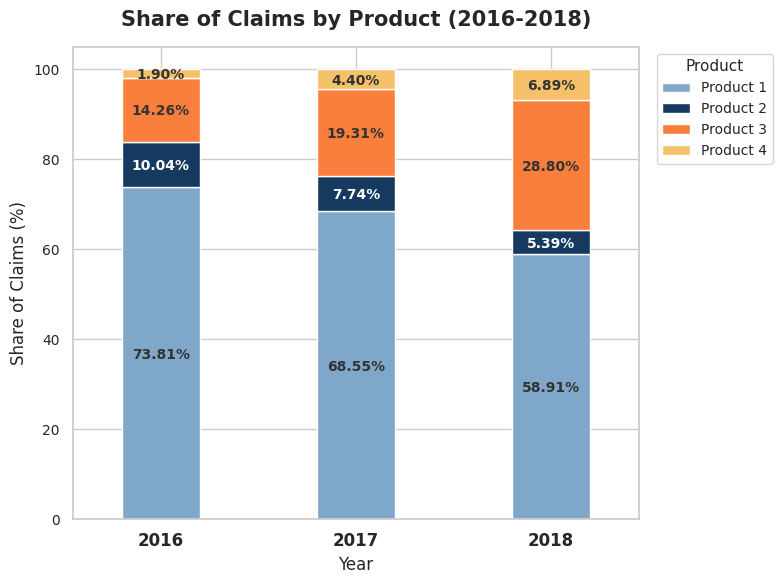

In [209]:
# data visualization for 1.a.1.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))
claims_pct.plot(kind='bar', stacked=True, color=colors, width=0.4, ax=ax)

# add percentage labels
for product in claims_pct.columns:
    for i, year in enumerate(claims_pct.index):
        value = claims_pct.loc[year, product]

        if value < 1:
            continue

        bottom = claims_pct.loc[year, claims_pct.columns[:claims_pct.columns.get_loc(product)]].sum()
        y_position = bottom + value / 2

        text_color = 'white' if product == 'Product 2' else '#333333'
        ax.text(i, y_position, f'{value:.2f}%', ha='center', va='center_baseline', fontsize=10, fontweight='bold', color=text_color)

ax.set_title('Share of Claims by Product (2016-2018)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Share of Claims (%)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(title='Product', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10, title_fontsize=11)
plt.xticks(rotation=0, fontsize=12, fontweight='bold')
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [210]:
# 1.a.2.
# 100% stacked bar graph showing the number of patients of each product per year
patients_pivot = (
    df_mkt.groupby(
    ['Claim_Year', 'Product_Name'])['Patient_ID']
    .nunique()
    .unstack(['Product_Name'])[product_order]
)
patients_pivot['Total'] = patients_pivot.sum(axis=1)

patients_pivot


Product_Name,Product 1,Product 2,Product 3,Product 4,Total
Claim_Year,,,,,
2016,2017,395,544,81,3037
2017,2155,398,862,229,3644
2018,2021,283,1266,367,3937


In [211]:
patients_pct = round(patients_pivot[product_order].div(patients_pivot['Total'], axis=0) * 100, 2)

patients_pct

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,66.41,13.01,17.91,2.67
2017,59.14,10.92,23.66,6.28
2018,51.33,7.19,32.16,9.32


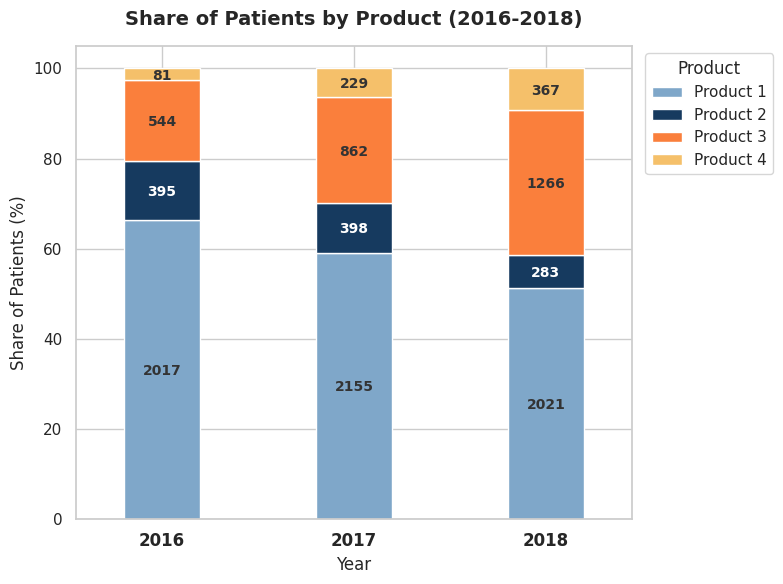

In [212]:
# data visualization for 1.a.2.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))
patients_pct.plot(kind='bar', stacked=True, color=colors, width=0.4, ax=ax)

# add percentage labels
for product in patients_pct.columns:
    for i, year in enumerate(patients_pct.index):
        value = patients_pct.loc[year, product]
        bottom = patients_pct.loc[year, patients_pct.columns[:patients_pct.columns.get_loc(product)]].sum()
        y_position = bottom + value / 2
        count = int(patients_pivot.loc[year, product])

        text_color = 'white' if product == 'Product 2' else '#333333'
        ax.text(i, y_position, f'{count}', ha='center', va='center_baseline',
                fontsize=10, fontweight='bold', color=text_color)

ax.set_title('Share of Patients by Product (2016-2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Share of Patients (%)')
ax.set_ylim(0, 105)
ax.legend(title='Product', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [213]:
# 1.a.3.
# 100% stacked bar graph showing the number of HCPs (I.e., writers) writing claims for each product per year
hcp_pivot = (
    df_mkt.groupby(
    ['Claim_Year', 'Product_Name'])['HCP_ID']
    .nunique()
    .unstack(['Product_Name'])[product_order]
  )
hcp_pivot['Total'] = hcp_pivot.sum(axis=1)

hcp_pivot

Product_Name,Product 1,Product 2,Product 3,Product 4,Total
Claim_Year,,,,,
2016,492,285,344,72,1193
2017,495,276,416,187,1374
2018,496,226,468,268,1458


In [214]:
hcp_pct = round(hcp_pivot[product_order].div(hcp_pivot['Total'], axis=0) * 100, 2)

hcp_pct

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,41.24,23.89,28.83,6.04
2017,36.03,20.09,30.28,13.61
2018,34.02,15.50,32.10,18.38


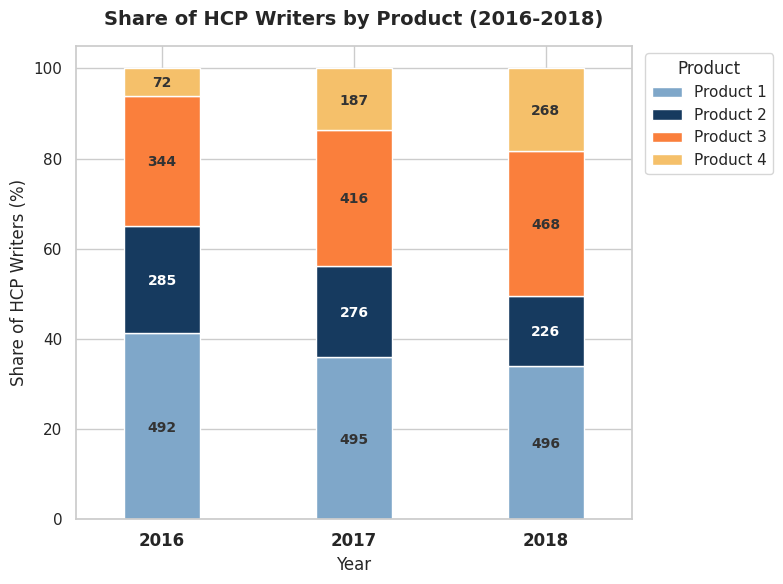

In [215]:
# data visualization for 1.a.3.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))
hcp_pct.plot(kind='bar', stacked=True, color=colors, width=0.4, ax=ax)

for product in hcp_pct.columns:
    for i, year in enumerate(hcp_pct.index):
        value = hcp_pct.loc[year, product]
        bottom = hcp_pct.loc[year, hcp_pct.columns[:hcp_pct.columns.get_loc(product)]].sum()
        y_position = bottom + value / 2
        count = int(hcp_pivot.loc[year, product])

        text_color = 'white' if product == 'Product 2' else '#333333'
        ax.text(i, y_position, f'{count}', ha='center', va='center_baseline',
                fontsize=10, fontweight='bold', color=text_color)

ax.set_title('Share of HCP Writers by Product (2016-2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Share of HCP Writers (%)')
ax.set_ylim(0, 105)
ax.legend(title='Product', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### 1.a.4. Observations & Actionable Recommendations

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
<span style="background-color:#3F9D34; color:#FFFFFF; padding:1px 6px; border-radius:5px;"><strong>Share of Claims</strong></span><br>
<strong>Observation</strong>: Product 3 is the primary beneficiary of Product 1's declining market leadership, capturing 28.80% of total claims in 2018, up from 14.26% in 2016, while Product 2 contracted from 10.04% to 5.39% over the same period. Notably, the overall market expanded from 4,272 to 5,600 annual claims, confirming that Product 2's erosion is driven by competitive displacement rather than market contraction.<br>

<strong>Recommendation</strong>: Realign sales force targeting toward Product 1 writers who are at risk of migration to Product 3. Given the growing market, converting even a fraction of Product 3's incremental share gain into Product 2 adoption would represent a meaningful recovery in competitive positioning.
<br><br>

<span style="background-color:#3F9D34; color:#FFFFFF; padding:1px 6px; border-radius:5px;"><strong>Share of Patients</strong></span><br>
<strong>Observation</strong>: Product 3 nearly doubled its unique patient base from 544 (17.91%) in 2016 to 1,266 (32.16%) in 2018, while Product 2's patient reach declined from 395 to 283 over the same period. The divergence in patient volume trends suggests Product 3 is succeeding not only in new patient acquisition but also in patient retention, an area where Product 2 is underperforming.<br>

<strong>Recommendation</strong>: Implement structured patient retention initiatives, including copay support and treatment adherence programs, to reduce mid-treatment attrition from Product 2. Stabilizing the existing patient base is a prerequisite before any meaningful share recovery can be achieved.
<br><br>

<span style="background-color:#3F9D34; color:#FFFFFF; padding:1px 6px; border-radius:5px;"><strong>Share of HCP Writers</strong></span><br>
<strong>Observation</strong>: The total HCP writer base in the injectable anesthesia market grew from 1,193 in 2016 to 1,458 in 2018, indicating active market expansion. However, Product 2 failed to benefit from this growth: its writer count declined from 285 to 226, while Product 3 added 124 net new writers over the same period. This pattern suggests that newly entering HCPs are disproportionately initiating with Product 3, further entrenching its competitive advantage.<br>

<strong>Recommendation</strong>: Prioritize early engagement with HCPs new to the injectable anesthesia segment before brand preference is established. Field force efforts should be supplemented with medical education and peer-to-peer programs to establish Product 2's clinical differentiation at the point of prescriber onboarding.
</div>

### **1.b. Claims per HCP and Patients per HCP per Year**

Calculate and analyze the number of claims per HCP (writer) and the number of patients per HCP for each product.

#### 1.b.1. Number of Claims per Writer per Year

In [216]:
# 1.b.1.
# A line graph showing the number of claims per writer per year
# Calculate claims per writer = total claims / unique HCPs per product per year
claims_per_writer = round(claims_pivot[product_order] / hcp_pivot[product_order], 2)

claims_per_writer

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,6.41,1.51,1.77,1.12
2017,7.46,1.51,2.50,1.27
2018,6.65,1.34,3.45,1.44


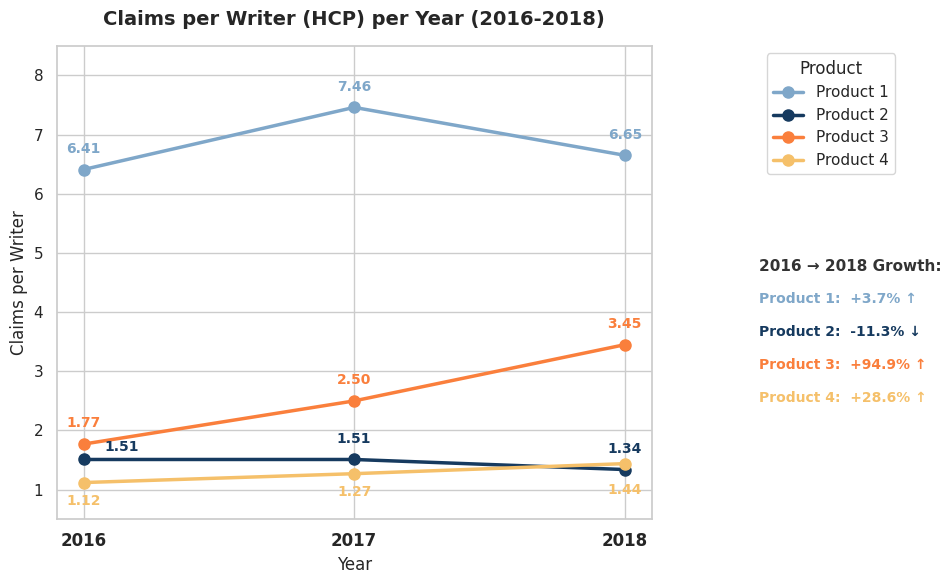

In [217]:
# data visualization  for 1.b.1.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

offset_map = {
    'Product 1': (0, 12),
    'Product 2': (0, 12),
    'Product 3': (0, 12),
    'Product 4': (0, -16),
}

ha_map = {
    'Product 1': 'center',
    'Product 2': 'center',
    'Product 3': 'center',
    'Product 4': 'center',
}

for i, product in enumerate(product_order):
    ax.plot(claims_per_writer.index, claims_per_writer[product],
            marker='o', linewidth=2.5, markersize=8,
            label=product, color=colors[i])
    x_off, y_off = offset_map[product]
    for x, y in zip(claims_per_writer.index, claims_per_writer[product]):
        # Special case: nudge Product 2's 2016 label to the right
        if product == 'Product 2' and x == 2016:
            ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(15, 6),
                        textcoords='offset points', ha='left',
                        fontsize=10, fontweight='bold', color=colors[i])
        # Special case: push Product 4's 2018 label further BELOW the line
        elif product == 'Product 4' and x == 2018:
            ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(0, -22),
                        textcoords='offset points', ha='center',
                        fontsize=10, fontweight='bold', color=colors[i])
        else:
            ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(x_off, y_off),
                        textcoords='offset points', ha=ha_map[product],
                        fontsize=10, fontweight='bold', color=colors[i])

# Calculate growth % from 2016 to 2018
growth_text = []
for i, product in enumerate(product_order):
    start = claims_per_writer.loc[2016, product]
    end = claims_per_writer.loc[2018, product]
    pct = round(((end - start) / start) * 100, 1)
    arrow = '↑' if pct > 0 else '↓'
    sign = '+' if pct > 0 else ''
    growth_text.append((product, f'{sign}{pct}% {arrow}', colors[i]))

# Growth summary panel on the right
ax.text(1.18, 0.55, '2016 → 2018 Growth:',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        ha='left', va='top', color='#333')

y_pos = 0.48
for product, text, color in growth_text:
    ax.text(1.18, y_pos, f'{product}:  {text}',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            ha='left', va='top', color=color)
    y_pos -= 0.07

ax.set_title('Claims per Writer (HCP) per Year (2016-2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Claims per Writer')
ax.set_xticks(claims_per_writer.index)
ax.set_ylim(0.5, 8.5)
ax.legend(title='Product', bbox_to_anchor=(1.18, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### 1.b.2. Number of Patients per Writer per Year

In [218]:
# 1.b.2.
# A line graph showing the number of patients per writer per year
# Calculate patients per writer = unique patients / unique HCPs per product per year
patients_per_writer = round(patients_pivot[product_order] / hcp_pivot[product_order], 2)

patients_per_writer

Product_Name,Product 1,Product 2,Product 3,Product 4
Claim_Year,,,,
2016,4.10,1.39,1.58,1.12
2017,4.35,1.44,2.07,1.22
2018,4.07,1.25,2.71,1.37


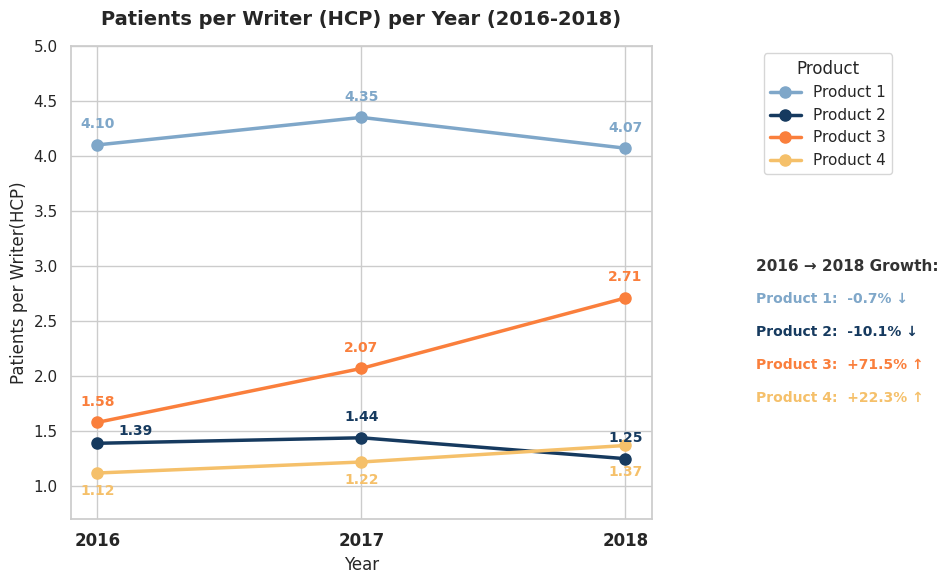

In [219]:
# data visualization for 1.b.2.
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

offset_map = {
    'Product 1': (0, 12),
    'Product 2': (0, 12),
    'Product 3': (0, 12),
    'Product 4': (0, -16),
}

ha_map = {
    'Product 1': 'center',
    'Product 2': 'center',
    'Product 3': 'center',
    'Product 4': 'center',
}

for i, product in enumerate(product_order):
    ax.plot(patients_per_writer.index, patients_per_writer[product],
            marker='o', linewidth=2.5, markersize=8,
            label=product, color=colors[i])
    x_off, y_off = offset_map[product]
    for x, y in zip(patients_per_writer.index, patients_per_writer[product]):
        if product == 'Product 2' and x == 2016:
            ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(15, 6),
                        textcoords='offset points', ha='left',
                        fontsize=10, fontweight='bold', color=colors[i])
        elif product == 'Product 4' and x == 2018:
            ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(0, -22),
                        textcoords='offset points', ha='center',
                        fontsize=10, fontweight='bold', color=colors[i])
        else:
            ax.annotate(f'{y:.2f}', xy=(x, y), xytext=(x_off, y_off),
                        textcoords='offset points', ha=ha_map[product],
                        fontsize=10, fontweight='bold', color=colors[i])

# Calculate growth % from 2016 to 2018
growth_text = []
for i, product in enumerate(product_order):
    start = patients_per_writer.loc[2016, product]
    end = patients_per_writer.loc[2018, product]
    pct = round(((end - start) / start) * 100, 1)
    arrow = '↑' if pct > 0 else '↓'
    sign = '+' if pct > 0 else ''
    growth_text.append((product, f'{sign}{pct}% {arrow}', colors[i]))

ax.text(1.18, 0.55, '2016 → 2018 Growth:',
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        ha='left', va='top', color='#333')

y_pos = 0.48
for product, text, color in growth_text:
    ax.text(1.18, y_pos, f'{product}:  {text}',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            ha='left', va='top', color=color)
    y_pos -= 0.07

ax.set_title('Patients per Writer (HCP) per Year (2016-2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Patients per Writer(HCP)')
ax.set_xticks(patients_per_writer.index)
ax.set_ylim(0.7, 5.0)
ax.legend(title='Product', bbox_to_anchor=(1.18, 1), loc='upper left')
plt.xticks(rotation=0, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#### 1.b.3. Observations & Actionable Recommendations

**Claims per Writer**
**Observation**: Product 3's per-writer productivity nearly doubled between 2016 and 2018, growing from 1.77 to 3.45 claims per writer (+94.9%), while Product 2 declined from 1.51 to 1.34 (-11.3%) over the same period. Product 1 remained the dominant productivity leader at approximately 6.5 claims per writer, reflecting an established prescriber base writing high volumes per HCP. The contrast between Product 3's accelerating productivity and Product 2's flat-to-declining trend suggests that Product 3 prescribers are not only more numerous but are also deepening their utilization of the product over time, indicating stronger brand entrenchment at the HCP level.

**Recommendation**: Implement HCP-level engagement programs to convert Product 2's existing prescribers from occasional writers into frequent prescribers. Field force efforts should prioritize structured speaker programs led by high-volume Product 2 advocates, supplemented by targeted clinical education on broader use cases. Account-management touchpoints should focus on prescribers writing Product 2 in fewer than two cases per year to identify and address the barriers limiting deeper adoption.

**Patients per Writer**
**Observation**: Product 3's average patient base per writer expanded 71.5% from 1.58 in 2016 to 2.71 in 2018, while Product 2's patients per writer declined 10.1% from 1.39 to 1.25 over the same period. Product 1 remained stable at approximately 4.0 patients per writer, reflecting an established legacy patient base. The divergence indicates that Product 3 prescribers are progressively widening the patient population they treat with the brand, while Product 2 prescribers are doing the opposite — narrowing the patient cohort placed on Product 2. This pattern suggests Product 2 is increasingly being reserved for a smaller subset of cases per HCP, further compounding its share erosion.

**Recommendation**: Develop differentiated clinical messaging and case-based selling materials that demonstrate the appropriate patient profiles for Product 2, equipping prescribers to expand rather than narrow their treatment population. Pair this with a structured patient identification toolkit that helps HCPs recognize Product 2-eligible patients earlier in the treatment decision, before alternative brands are considered.

### **1.c. Top 5 Territories with Biggest YoY Drop for Product 2 (2017 → 2018)**

Find the top 5 territories with the most drop in claims volume from 2017 to 2018 for the variant brand (Product 2 - J2250) and compare with the competitor brand (Product 3 - J3010).

In [220]:
# 1.c.i.
# Territory-level claims volume per product per year
terr_pivot = (
    df_mkt.groupby(['Territory Name', 'Claim_Year', 'Product_Name'])['Claim_ID']
          .count()
          .unstack('Product_Name'))
terr_pivot.head(12)

Product_Name               Product 1  Product 2  Product 3  Product 4
Territory Name Claim_Year                                            
Albany, NY     2016            128.0       14.0       35.0        6.0
               2017            157.0       20.0       39.0        9.0
               2018            137.0       19.0       68.0       23.0
Atlanta, GA    2016            145.0       19.0       32.0        2.0
               2017            195.0       24.0       37.0       11.0
               2018            172.0       17.0       81.0       21.0
Birmingham, AL 2016             48.0        4.0       11.0        1.0
               2017             43.0        8.0       21.0        6.0
               2018             45.0        5.0       21.0        6.0
Boston, MA     2016            228.0       33.0       33.0        6.0
               2017            253.0       34.0       80.0       20.0
               2018            208.0       25.0      116.0       27.0

In [221]:
# 1.c.ii.
# YoY % change for Product 2 (J2250) between 2017 and 2018
p2_terr = terr_pivot['Product 2'].unstack('Claim_Year').fillna(0)

# Keep only territories with claims in 2017 so that YoY % is well-defined
p2_terr = p2_terr[p2_terr[2017] > 0].copy()

p2_terr['YoY_2017_2018_pct'] = round(((p2_terr[2018] - p2_terr[2017]) / p2_terr[2017]) * 100, 2)

p2_terr.head()

Claim_Year,2016,2017,2018,YoY_2017_2018_pct
Territory Name,,,,
"Albany, NY",14.0,20.0,19.0,-5.00
"Atlanta, GA",19.0,24.0,17.0,-29.17
"Birmingham, AL",4.0,8.0,5.0,-37.50
"Boston, MA",33.0,34.0,25.0,-26.47
"Charlotte, NC",8.0,5.0,6.0,20.00


In [222]:
# 1.c.iii.
# Sort territories from smallest to largest YoY % change
p2_terr_sorted = p2_terr.sort_values('YoY_2017_2018_pct')

p2_terr_sorted.head(10)

Claim_Year,2016,2017,2018,YoY_2017_2018_pct
Territory Name,,,,
"St Louis, MO",19.0,22.0,6.0,-72.73
"Phoenix, AZ",11.0,10.0,3.0,-70.00
"LA-San Diego, CA",29.0,38.0,16.0,-57.89
"New York, NY",24.0,40.0,17.0,-57.50
"Minneapolis, MN",15.0,15.0,7.0,-53.33
"Birmingham, AL",4.0,8.0,5.0,-37.50
"Dallas, TX",28.0,20.0,13.0,-35.00
"Philedelphia, PA",30.0,27.0,18.0,-33.33
"Atlanta, GA",19.0,24.0,17.0,-29.17


In [223]:
# 1.c.iv.
# Take the top 5 territories with smallest YoY % (biggest drop in claims volume from 2017 - 2018)
top5_drop = p2_terr_sorted.head(5)
top5_terrs = top5_drop.index.tolist()

# Display the top 5 drop table
print("Top 5 territories with biggest Product 2 drop (2017 → 2018):")
display(top5_drop)

print(f"\nTerritories: {top5_terrs}\n")

# Extract claims count for Product 2 and Product 3 across 2016-2018 for these 5 territories
p2_top5 = terr_pivot['Product 2'].unstack('Claim_Year').reindex(top5_terrs).fillna(0).astype(int)
p3_top5 = terr_pivot['Product 3'].unstack('Claim_Year').reindex(top5_terrs).fillna(0).astype(int)

print("Product 2 (Variant Brand) claims in top 5 drop territories:")
display(p2_top5)

print("\nProduct 3 (Main Competitor) claims in same territories:")
display(p3_top5)



Top 5 territories with biggest Product 2 drop (2017 → 2018):


Claim_Year,2016,2017,2018,YoY_2017_2018_pct
Territory Name,,,,
"St Louis, MO",19.0,22.0,6.0,-72.73
"Phoenix, AZ",11.0,10.0,3.0,-70.00
"LA-San Diego, CA",29.0,38.0,16.0,-57.89
"New York, NY",24.0,40.0,17.0,-57.50
"Minneapolis, MN",15.0,15.0,7.0,-53.33



Territories: ['St Louis, MO', 'Phoenix, AZ', 'LA-San Diego, CA', 'New York, NY', 'Minneapolis, MN']

Product 2 (Variant Brand) claims in top 5 drop territories:


Claim_Year,2016,2017,2018
Territory Name,,,
"St Louis, MO",19,22,6
"Phoenix, AZ",11,10,3
"LA-San Diego, CA",29,38,16
"New York, NY",24,40,17
"Minneapolis, MN",15,15,7



Product 3 (Main Competitor) claims in same territories:


Claim_Year,2016,2017,2018
Territory Name,,,
"St Louis, MO",23,40,54
"Phoenix, AZ",7,23,32
"LA-San Diego, CA",55,86,99
"New York, NY",33,81,153
"Minneapolis, MN",14,37,50


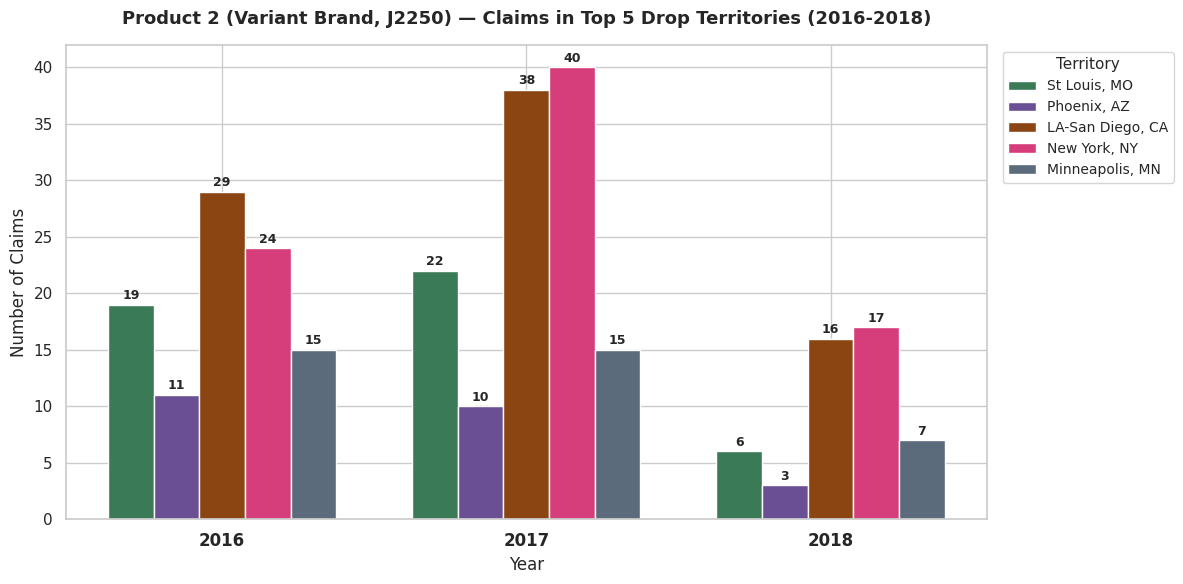

In [224]:
# 1.c.v.1
# Clustered bar chart: Product 2 claims in top 5 drop territories (2016-2018)
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

# Consistent territory colors so the same territory uses the same color in both charts
territory_palette = ['#3B7A57', '#6B4F94', '#8B4513', '#D63E7B', '#5B6B7B']
territory_colors = dict(zip(top5_terrs, territory_palette))

years = [2016, 2017, 2018]
x = np.arange(len(years))
width = 0.15

for i, terr in enumerate(top5_terrs):
    vals = [p2_top5.loc[terr, y] if y in p2_top5.columns else 0 for y in years]
    bars = ax.bar(x + i * width, vals, width,
                  label=terr, color=territory_colors[terr],
                  edgecolor='white', linewidth=1)
    # add value labels on top of each bar
    for bar, val in zip(bars, vals):
        ax.annotate(f'{int(val)}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold')

ax.set_title('Product 2 (Variant Brand, J2250) — Claims in Top 5 Drop Territories (2016-2018)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Claims', fontsize=12)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(years, fontsize=12, fontweight='bold')
ax.legend(title='Territory', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

#### 1.c.v.2. Clustered Bar Chart — Product 3 (Main Competitor, J3010) in Same 5 Territories

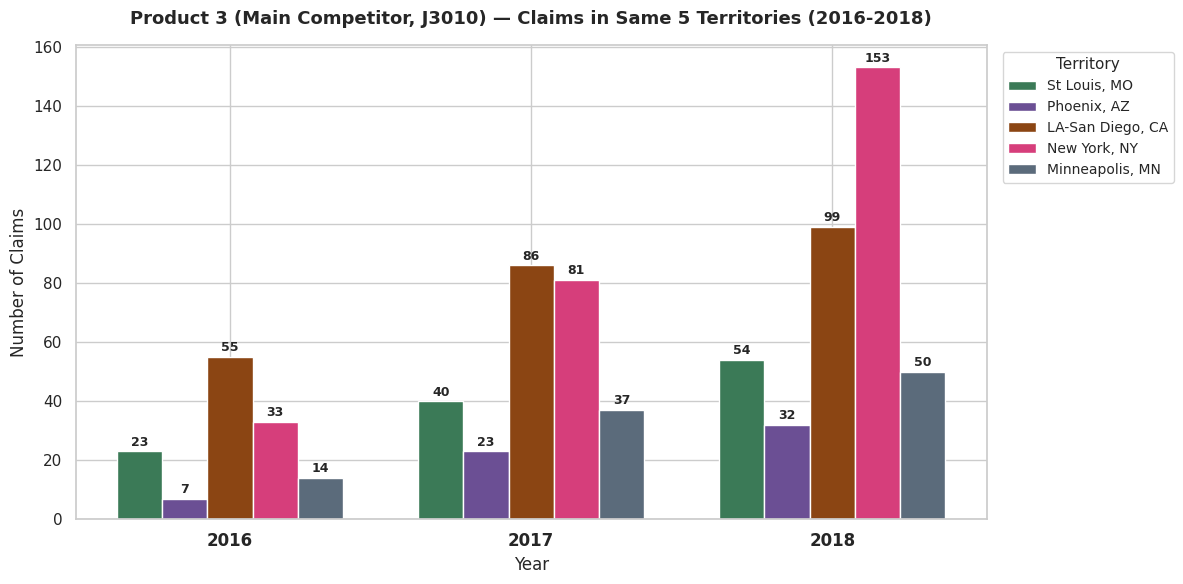

In [225]:
# 1.c.v.2
# Clustered bar chart: Product 3 (Main Competitor) claims in same 5 territories (2016-2018)
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

years = [2016, 2017, 2018]
x = np.arange(len(years))
width = 0.15

for i, terr in enumerate(top5_terrs):
    vals = [p3_top5.loc[terr, y] if y in p3_top5.columns else 0 for y in years]
    bars = ax.bar(x + i * width, vals, width,
                  label=terr, color=territory_colors[terr],
                  edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax.annotate(f'{int(val)}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold')

ax.set_title('Product 3 (Main Competitor, J3010) — Claims in Same 5 Territories (2016-2018)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Claims', fontsize=12)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(years, fontsize=12, fontweight='bold')
ax.legend(title='Territory', bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

#### 1.c.v.3. Side-by-Side Comparison — Variant Brand vs. Main Competitor

These charts compare and contrast the relative growth of J3010 compared to the variant brand in these 5 territories for each year, especially between 2017 and 2018.

The figure below pairs the two clustered bar charts above with a shared y-axis and consistent territory colors, allowing visual comparison of how Product 3 grew in the same territories where Product 2 contracted between 2017 and 2018.

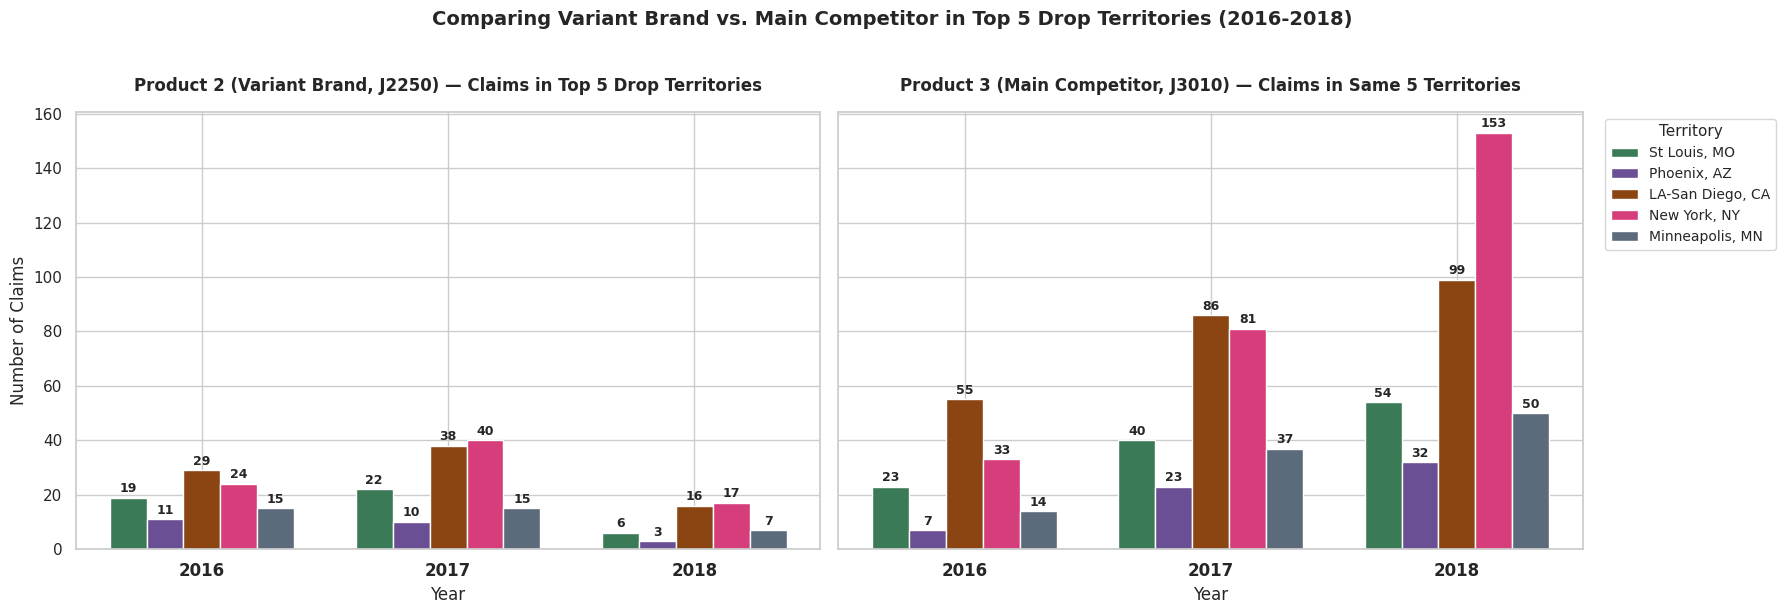

In [226]:
# 1.c.v.1 + v.2 combined — side-by-side comparison
sns.set_theme(style='whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

years = [2016, 2017, 2018]
x = np.arange(len(years))
width = 0.15

# Left chart: Product 2 (Variant Brand)
for i, terr in enumerate(top5_terrs):
    vals = [p2_top5.loc[terr, y] if y in p2_top5.columns else 0 for y in years]
    bars = ax1.bar(x + i * width, vals, width,
                   label=terr, color=territory_colors[terr],
                   edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax1.annotate(f'{int(val)}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

ax1.set_title('Product 2 (Variant Brand, J2250) — Claims in Top 5 Drop Territories',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Claims', fontsize=12)
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(years, fontsize=12, fontweight='bold')

# Right chart: Product 3 (Main Competitor)
for i, terr in enumerate(top5_terrs):
    vals = [p3_top5.loc[terr, y] if y in p3_top5.columns else 0 for y in years]
    bars = ax2.bar(x + i * width, vals, width,
                   label=terr, color=territory_colors[terr],
                   edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax2.annotate(f'{int(val)}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

ax2.set_title('Product 3 (Main Competitor, J3010) — Claims in Same 5 Territories',
              fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(years, fontsize=12, fontweight='bold')

# Single shared legend on the right
ax2.legend(title='Territory', bbox_to_anchor=(1.02, 1), loc='upper left',
           fontsize=10, title_fontsize=11)

plt.suptitle('Comparing Variant Brand vs. Main Competitor in Top 5 Drop Territories (2016-2018)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 1.c.4. Differentiated Strategy — Highly Populated Territories vs. Mid-Term Territories

**Observation**: Although all five drop territories share a similar claim-volume decline pattern (-53% to -73%), the underlying HCP and patient populations are fundamentally different between highly populated metros and Mid-Term territories, which means a uniform recovery strategy would be inefficient. New York, LA-San Diego, and St Louis are large metro markets with deep HCP pools and broad patient bases — Product 2 lost 23, 22, and 16 claims respectively, but each lost claim represents a small fraction of a much larger prescriber and patient ecosystem. Phoenix and Minneapolis are Mid-Term territories with smaller absolute losses (7 and 8 claims) but substantially more concentrated HCP populations, where a single high-volume prescriber may account for a meaningful share of territory-level claims. The same -70% claim drop carries very different operational implications: in metros it points to scale-driven competitive pressure, while in Mid-Terms it points to the loss of a small number of high-value prescriber relationships.

**Recommendation**: Apply differentiated tactics by territory type. In highly populated metros (New York, LA-San Diego, St Louis), deploy broader sales-force coverage, peer-to-peer speaker programs at major academic medical centers, and non-personal promotion (digital, email, conference outreach) to scale efficiently across the larger HCP pool. In Mid-Term territories (Phoenix, Minneapolis), prioritize one-to-one account management with the small set of remaining high-value prescribers, supplemented by intensive clinical evidence sharing, sample programs, and direct medical-affairs engagement to defend each individual prescriber relationship before further attrition occurs. Resource allocation between the two territory types should reflect HCP density and revenue potential, not just absolute claim volume change.

#### 1.c.5. Observations & Actionable Recommendations

**Observation**: The two clustered bar charts above reveal a clear competitive displacement pattern. In the five territories where Product 2 experienced the largest year-over-year claim declines between 2017 and 2018 — St Louis, MO (-72.7%), Phoenix, AZ (-70.0%), LA-San Diego, CA (-57.9%), New York, NY (-57.5%), and Minneapolis, MN (-53.3%) — Product 3 simultaneously expanded its claims volume in every single territory over the same period. The 2016-2017 trend for Product 2 was largely positive or stable in these markets (e.g., New York grew from 24 to 40 claims; St Louis grew from 19 to 22), but collapsed sharply in 2018, while Product 3 continued its upward trajectory uninterrupted. The most striking case is New York, where Product 2 fell from 40 to 17 claims while Product 3 nearly doubled from 81 to 153 claims. This pattern indicates that the 2018 erosion was not a gradual market shift but a discrete competitive displacement event in which Product 3 captured demand directly from the Product 2 prescriber base in these specific geographies.

**Recommendation**: Initiate a targeted account recovery program in these five territories within the next two sales cycles. Field force coverage should be intensified through dedicated account executives and physician-level retention outreach, with priority given to identifying which Product 2 prescribers switched to Product 3 between 2017 and 2018. Win-back campaigns should be tailored to address the specific clinical or commercial triggers that drove the switch.

### **2. Identifying the trends of the Key Market Drivers of the Injectable Anesthesia Market**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
You got to know from the Primary market research team that the Patient Age, Specialty of the patient diagnosis, HCP Specialty and New prescriber growth are the key Market Drivers of the Injectable anesthetics. Investigate these metrics and their trends. How could you leverage the trends of these key market drivers to increase your market share for Product 2? How could these trends relate to the competitor brand's growth (Product 3) and your Variant brand's decline (Product 2)?
</div>

### **3. Strategies to stop the market share erosion and gain traction in the market for the Variant Brand**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
You may convince your leadership to increase the budget and/or labor resources to gain market leadership. The analyses you have done so far should support the recommendations. What are the key business areas or metrics that require attention based on the metrics analyzed so far? Based on your observations, what are the strategic recommendations you would offer to the on-field sales force and promotional strategies. How can improvements be made to target specific customer segments, optimize the sales force, and enhance non-personal promotions? Your solution should include actionable steps to stop the eroding market share of the Variant Brand immediately as a priority.
</div>

### **4. Data Exploration Opportunities:**

<div style="
    line-height: 1.6;
    text-align: justify;
    text-align-last: left;
    max-width: calc(100% - 80px);
">
What are the analyses you would pursue out of the scope of the given Medicare claims data? Do you have any concerns with the data? If so, why, and what actionable steps would you take to resolve this while not losing sight of the primary goal of arresting the losing market erosion? What data gaps did you find in the given data and what other datasets can help you fill this and provide the data summaries you want for this case?
</div>